Load essential libraries for data manipulation, visualization, and clustering. 
Loading the dataset is the foundational step to begin data analysis and exploration.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv('CC GENERAL.csv')
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


Removing CUST_ID, which is an identifier column that does not add value to the clustering process. Including such columns would distort distance calculations without providing meaningful insights

In [3]:
df.drop(['CUST_ID'], axis=1, inplace=True)
df.shape

(8950, 17)

Assessing data quality by checking for missing or infinite values, which could affect clustering performance and accuracy. Identifying these values helps prepare for appropriate data cleaning steps.

In [5]:
df.isna().sum(), np.isinf(df).sum()

(BALANCE                               0
 BALANCE_FREQUENCY                     0
 PURCHASES                             0
 ONEOFF_PURCHASES                      0
 INSTALLMENTS_PURCHASES                0
 CASH_ADVANCE                          0
 PURCHASES_FREQUENCY                   0
 ONEOFF_PURCHASES_FREQUENCY            0
 PURCHASES_INSTALLMENTS_FREQUENCY      0
 CASH_ADVANCE_FREQUENCY                0
 CASH_ADVANCE_TRX                      0
 PURCHASES_TRX                         0
 CREDIT_LIMIT                          1
 PAYMENTS                              0
 MINIMUM_PAYMENTS                    313
 PRC_FULL_PAYMENT                      0
 TENURE                                0
 dtype: int64,
 BALANCE                             0
 BALANCE_FREQUENCY                   0
 PURCHASES                           0
 ONEOFF_PURCHASES                    0
 INSTALLMENTS_PURCHASES              0
 CASH_ADVANCE                        0
 PURCHASES_FREQUENCY                 0
 ONEOFF_PURCHAS

Filling missing values using the median, a common strategy that minimizes the impact of outliers. Handling missing values is critical to ensure smooth execution of clustering algorithms, which do not handle NaNs.

In [7]:
df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median(), inplace=True)
df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median(), inplace=True)

df.isna().sum()

C:\Users\Shu\AppData\Local\Temp\ipykernel_15956\1176003071.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median(), inplace=True)
C:\Users\Shu\AppData\Local\Temp\ipykernel_15956\1176003071.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

Standardizing the data to have a mean of 0 and a standard deviation of 1. Scaling ensures that features with different scales contribute equally to the clustering process, which uses distance metrics sensitive to feature scales.

In [9]:
scaler = StandardScaler()

scaled_df = scaler.fit_transform(df)

Implementing the Elbow Method to determine the optimal number of clusters by examining within-cluster sum of squares (WCSS). Choosing the right k is crucial for meaningful clusters, balancing model simplicity with accuracy.

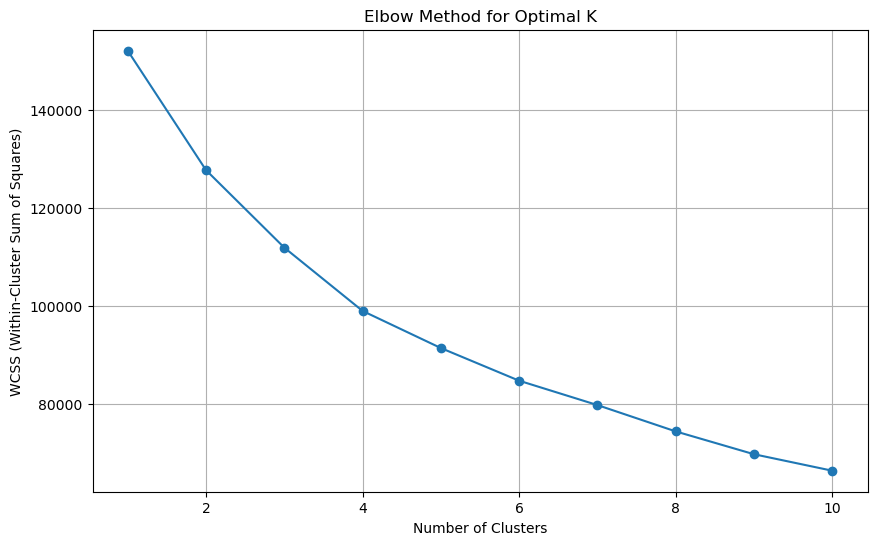

In [11]:
# Initializing a list to hold the WCSS values
wcss = []

# Calculating WCSS for a range of cluster numbers
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

In [ ]:
'''
Interpreting the Plot
In this plot:

The WCSS decreases sharply at first, from 1 to around 4 clusters.
After around 4 clusters, the rate of decrease in WCSS slows down, forming a more gradual slope.

Optimal Number of Clusters
The point where the elbow forms is often considered the optimal 𝑘. 
In this case, it looks like 4 clusters might be a reasonable choice, as this is where the reduction in WCSS starts to flatten out. However, 
we are you choosing to proceed with 5 clusters , which is also reasonable since it’s still within the range where WCSS significantly decreases.

'''

Running K-Means with the selected number of clusters and assigning each data point to a cluster. This step segments the dataset into meaningful groups, creating the basis for further analysis.

In [13]:
optimal_k = 5 

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_df)  # Adding cluster labels to the original DataFrame

Extracting cluster centers for each feature to interpret the characteristics of each cluster. Understanding cluster centers helps to describe the typical profile of each group.

In [15]:
# Creating a DataFrame to store cluster centers with their corresponding feature names
# Using the original feature names (not including 'Cluster')

feature_names = df.columns[:-1] 

# Creating the DataFrame with the correct shape
cluster_centers_df = pd.DataFrame(kmeans.cluster_centers_, columns=feature_names)

# Adding cluster labels
cluster_centers_df['Cluster'] = range(optimal_k)

# Displaying the cluster centers
print("Cluster Centers DataFrame:\n", cluster_centers_df)

Cluster Centers DataFrame:
     BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0 -0.247577          -0.340375  -0.339080         -0.221041   
1  0.162851           0.431421   0.899458          0.841986   
2  1.418215           0.418306   6.971111          6.138378   
3 -0.441322           0.106275  -0.095869         -0.256098   
4  1.458632           0.381355  -0.242357         -0.176790   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0               -0.395520     -0.172681            -0.814461   
1                0.579809     -0.294699             1.080752   
2                5.203140      0.029072             1.088591   
3                0.243770     -0.381893             0.912451   
4               -0.248347      1.730922            -0.525613   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                   -0.354361                         -0.751080   
1                    1.781796                          0.557226   
2      

Generating summary statistics for each cluster to compare and interpret the differences. Descriptive statistics provide insights into how clusters differ across features.

In [17]:
# Analyzing each cluster by printing descriptive statistics
for i in range(optimal_k):
    print(f"\nCluster {i} Profile:")
    print(df[df['Cluster'] == i].describe())


Cluster 0 Profile:
           BALANCE  BALANCE_FREQUENCY    PURCHASES  ONEOFF_PURCHASES  \
count  3910.000000        3910.000000  3910.000000       3910.000000   
mean   1050.105528           0.796663   278.943148        225.819926   
std    1115.712513           0.293609   478.975140        455.981384   
min       0.000000           0.000000     0.000000          0.000000   
25%     112.011980           0.636364     0.000000          0.000000   
50%     817.249403           1.000000    73.005000          0.000000   
75%    1551.282092           1.000000   350.000000        247.242500   
max    8115.039014           1.000000  4900.000000       4900.000000   

       INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
count             3910.000000   3910.000000          3910.000000   
mean                53.325698    618.399979             0.163437   
std                150.577878    939.271165             0.184837   
min                  0.000000      0.000000             0.0

Visualizing clusters in 2D and 3D space using selected features. These plots provide visual confirmation of cluster separation and reveal the relationships between key variables in each cluster.

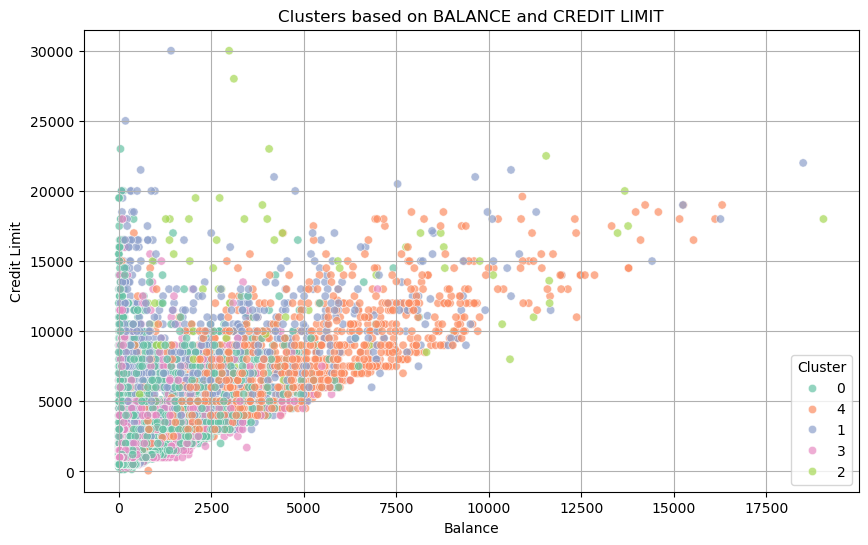

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Converting 'Cluster' to string for better color coding in the plot
df['Cluster'] = df['Cluster'].astype(str)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='BALANCE', y='CREDIT_LIMIT', hue='Cluster', palette='Set2', alpha=0.7)
plt.title('Clusters based on BALANCE and CREDIT LIMIT')
plt.xlabel('Balance')
plt.ylabel('Credit Limit')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

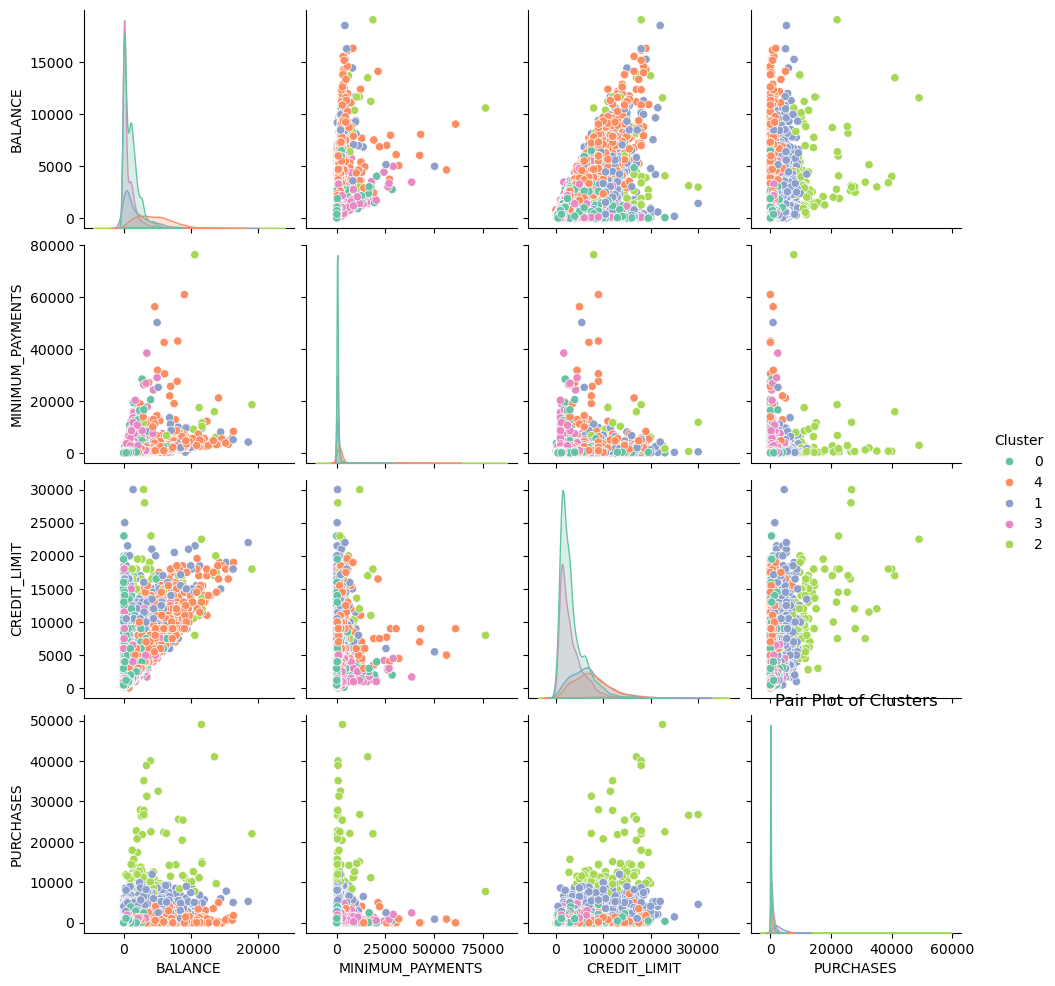

In [22]:
sns.pairplot(df, hue='Cluster', vars=['BALANCE', 'MINIMUM_PAYMENTS', 'CREDIT_LIMIT', 'PURCHASES'], palette='Set2')
plt.title('Pair Plot of Clusters')
plt.show()

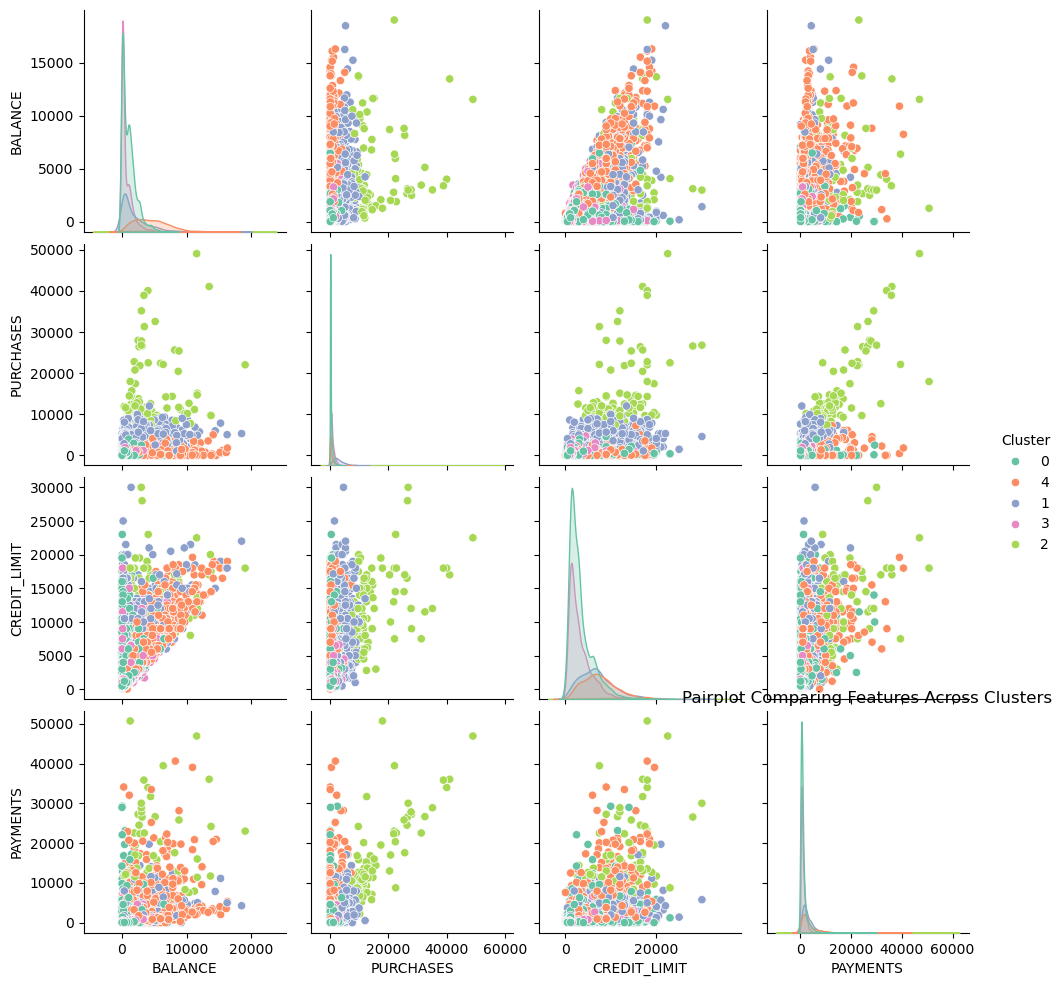

In [23]:
sns.pairplot(df, hue="Cluster", vars=['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'PAYMENTS'], palette="Set2")
plt.title("Pairplot Comparing Features Across Clusters")
plt.show()

Visualizing Centroids with Scatter Plot. Plotting cluster centroids on the scatter plot to identify the central points of each cluster. This helps interpret the average or typical position of each cluster in feature space.

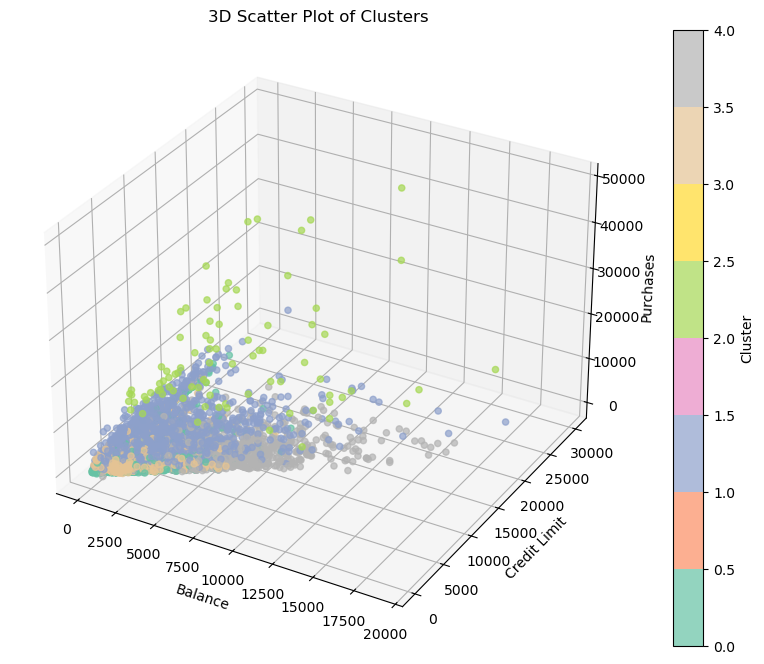

In [34]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(df['BALANCE'], df['CREDIT_LIMIT'], df['PURCHASES'], 
                     c=df['Cluster'].astype('category').cat.codes, 
                     cmap='Set2', alpha=0.7)

# Adding labels
ax.set_xlabel('Balance')
ax.set_ylabel('Credit Limit')
ax.set_zlabel('Purchases')
plt.title('3D Scatter Plot of Clusters')
plt.colorbar(scatter, label='Cluster')
plt.show()

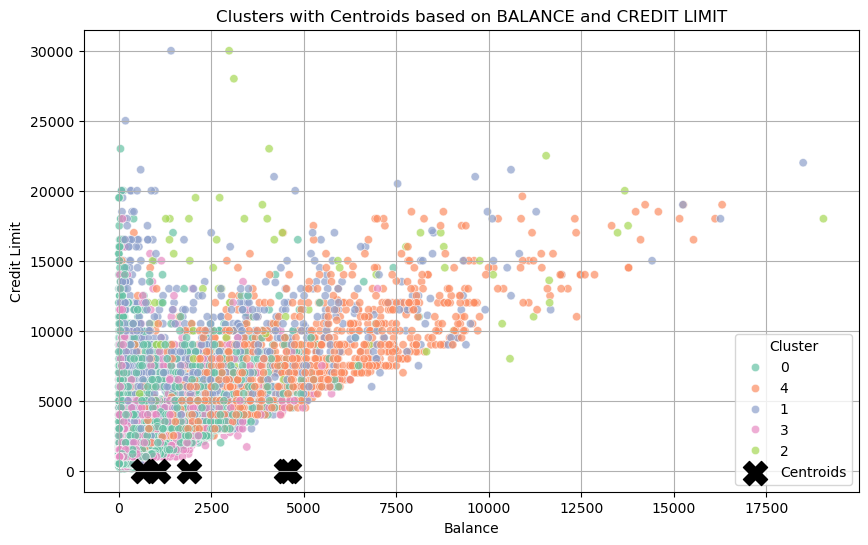

In [25]:
# Cluster centers in the original feature space
centroids = kmeans.cluster_centers_

# Inverse transform the centers to original scale
centroids_original = scaler.inverse_transform(centroids)

# Scatter plot with cluster centers
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='BALANCE', y='CREDIT_LIMIT', hue='Cluster', palette='Set2', alpha=0.7)
plt.scatter(centroids_original[:, 0], centroids_original[:, 1], s=300, color='black', marker='X', label='Centroids')
plt.title('Clusters with Centroids based on BALANCE and CREDIT LIMIT')
plt.xlabel('Balance')
plt.ylabel('Credit Limit')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

Box Plot for Balance by Cluster. It reveal the distribution of a single feature (e.g., BALANCE) across clusters. This helps identify clusters with higher or lower values, contributing to better understanding of customer segments.

C:\Users\Shu\AppData\Local\Temp\ipykernel_8316\1932562986.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Cluster', y='BALANCE', palette='Set2')


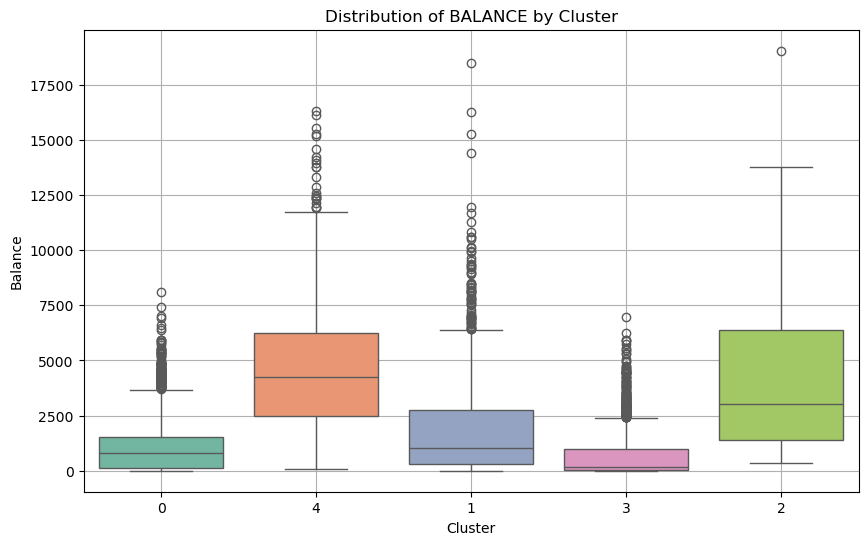

In [26]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Cluster', y='BALANCE', palette='Set2')
plt.title('Distribution of BALANCE by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Balance')
plt.grid(True)
plt.show()

Calculating and Displaying Cluster Summary Statistics. Calculating mean values for each feature within each cluster, along with the count of points. Summary statistics give a concise view of the main characteristics of each cluster.

In [19]:
cluster_summary = df.groupby('Cluster').mean()
cluster_summary['Count'] = df['Cluster'].value_counts()

print("Cluster Summary Statistics (Mean Values):\n")
print(cluster_summary)

Cluster Summary Statistics (Mean Values):

             BALANCE  BALANCE_FREQUENCY     PURCHASES  ONEOFF_PURCHASES  \
Cluster                                                                   
0        1050.105528           0.796663    278.943148        225.819926   
1        1904.691069           0.979485   2925.208433       1988.683126   
2        4516.369799           0.976364  15897.090235      10780.888000   
3         644.401406           0.902296    797.100936        167.277110   
4        4604.345571           0.967965    485.151896        298.426606   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
Cluster                                                              
0                     53.325698    618.399979             0.163437   
1                    936.958520    360.612509             0.924163   
2                   5116.202235   1039.836264             0.927255   
3                    630.317938    178.022789             0.856389   
4          

Visualizing the cluster centers across all features in a heatmap to see feature importance within each cluster. This aids in quickly spotting which features are dominant in each cluster.

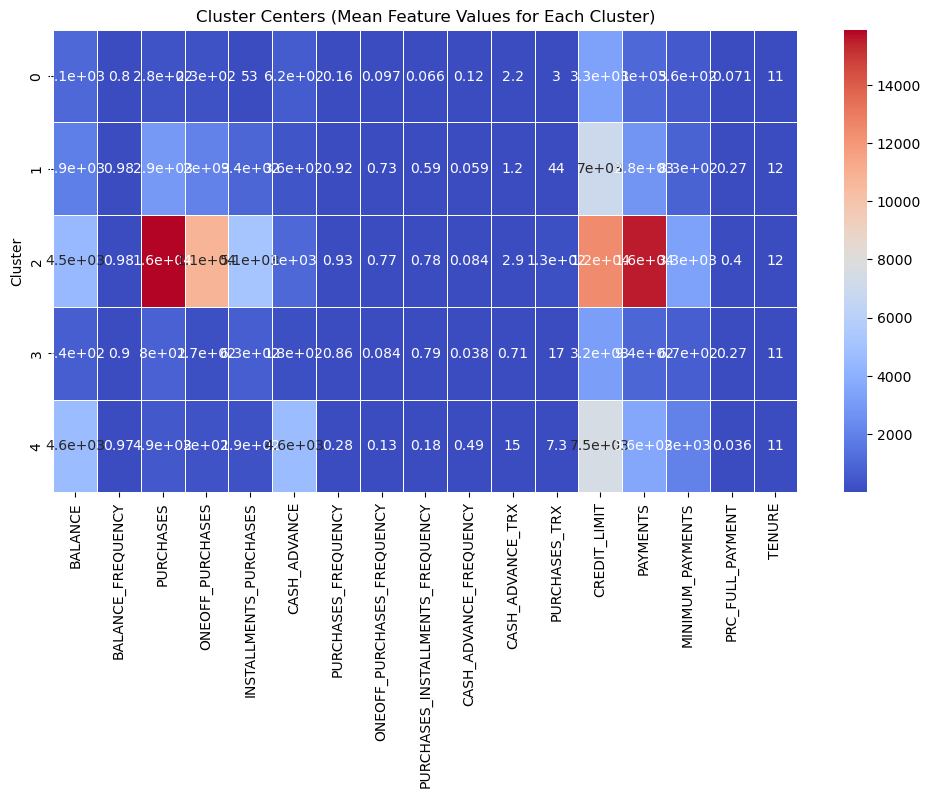

In [43]:
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_summary.drop('Count', axis=1), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Cluster Centers (Mean Feature Values for Each Cluster)")
plt.show()

Evaluating Silhouette Score and Davies-Bouldin Index to assess cluster quality. The silhouette score measures cluster separation, while the Davies-Bouldin Index gauges similarity between clusters. Together, these metrics help confirm if the clusters are well-defined and meaningful.

In [21]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Silhouette Score
silhouette_avg = silhouette_score(scaled_df, df['Cluster'])
print(f'Silhouette Score: {silhouette_avg}')

# Davies-Bouldin Index
davies_bouldin = davies_bouldin_score(scaled_df, df['Cluster'])
print(f'Davies-Bouldin Index: {davies_bouldin}')

Silhouette Score: 0.19311230479899416
Davies-Bouldin Index: 1.549203869382753


In [ ]:
'''

Silhouette Score of 0.193:
Silhouette scores range from -1 to 1, where values closer to 1 indicate better-defined clusters. A score of 0.193 is on the low side, suggesting that 
the clusters might not be very well-separated. In general, a silhouette score above 0.5 is considered strong, while scores between 0.25 and 0.5 are 
acceptable but may indicate overlapping clusters.
A low silhouette score can imply that some data points are not well-matched to their assigned cluster or that there is significant overlap between 
clusters.

Davies-Bouldin Index of 1.549:
The Davies-Bouldin Index measures how similar clusters are to each other, with lower values indicating better cluster separation. While there is no 
absolute "good" or "bad" threshold, values closer to zero indicate more distinct clusters. An index of 1.549 is moderate, indicating that there may be 
some overlap or similarity between clusters.

'''

In [ ]:
'''

Interpretation and Next Steps

Consider Reducing or Increasing the Number of Clusters:
Since the evaluation metrics indicate potential overlap, we can try slightly different values of k (e.g., 4 or 6 clusters) to see if the silhouette 
score improves. We may also revisit the elbow plot to see if there are any secondary inflection points that suggest a different cluster count.

Experimenting with Other Clustering Methods:
Hierarchical Clustering: This approach can reveal more about the nested structure of data and might result in more interpretable clusters for this 
dataset.
DBSCAN (Density-Based Spatial Clustering): This algorithm can be effective for identifying clusters of varying density and may perform better if there 
are natural "dense" regions in the data, such as high-spending groups.
Gaussian Mixture Models (GMM): This approach assumes clusters follow a Gaussian distribution and might better handle overlaps if the clusters aren’t 
distinctly separated in K-Means.

Examining Specific Features in Clusters with Overlap:
We may find that certain features are driving the overlap. Reviewing the pair plots or individual feature distributions across clusters can highlight 
which variables contribute most to overlap. For example, BALANCE vs. PURCHASES may show a lot of mixing between clusters, while others like 
CREDIT_LIMIT may be more distinct.

Further Interpret Clusters for Business Insights:

Despite the moderate cluster separation, the cluster profiles we derived may still yield useful insights. Looking for trends such as 
high vs. low spenders, balance maintainers vs. payers, or those with high credit utilization.
Using this understanding to target marketing strategies, product offerings, or customer service interventions tailored to each segment.

'''

Using density-based clustering validation refers to evaluating cluster compactness (i.e., intra-cluster distances) and separation (i.e., inter-cluster distances) to assess how "dense" and well-separated your clusters are.

Compactness: Within each cluster, calculate the average distance between points and the cluster's centroid (K-means).

Separation: Calculate the distance between the centroids of different clusters.

DBCV-like behavior: This methid is similar to Density-Based Clustering Validation (DBCV) for evaluating clustering quality which assess if the clusters are dense (compact) and well-separated.

In [26]:
import numpy as np
from sklearn.metrics import pairwise_distances_argmin_min
from sklearn.metrics import silhouette_score

# Function to calculate compactness (average distance to centroid)
def calculate_compactness(X, cluster_labels, centroids):
    compactness = []
    for i in range(len(centroids)):
        points_in_cluster = X[cluster_labels == i]
        centroid = centroids[i]
        dist = np.linalg.norm(points_in_cluster - centroid, axis=1)  # Calculate Euclidean distance
        compactness.append(np.mean(dist))
    return np.mean(compactness)

# Function to calculate separation (average distance between centroids)
def calculate_separation(centroids):
    distances = pairwise_distances_argmin_min(centroids, centroids)[1]  # pairwise distances between centroids
    return np.mean(distances)

# 1. Compactness of KMeans clusters (average distance from centroid)
compactness = calculate_compactness(scaled_df, df['Cluster'], kmeans.cluster_centers_)

# 2. Separation between clusters (average distance between centroids)
separation = calculate_separation(kmeans.cluster_centers_)

print(f"Cluster Compactness (average within-cluster distance): {compactness}")
print(f"Cluster Separation (average between-cluster distance): {separation}")

Cluster Compactness (average within-cluster distance): 4.24585621564764
Cluster Separation (average between-cluster distance): 0.0


1. Interpretation:
a) Cluster Compactness (average within-cluster distance) = 4.25:
Interpretation: The compactness score indicates how close the points within each cluster are to their respective centroids. A lower value is typically 
better, as it indicates that the points are closer to the centroid (i.e., the cluster is "tight" and dense).
In this case, the value is 4.25, which is somewhat high. This suggests that the clusters are not very tight, meaning the points within each cluster are 
relatively far from their cluster's centroid, which could indicate poor intra-cluster cohesion.

b) Cluster Separation (average between-cluster distance) = 0.0:
Interpretation: Separation measures how far apart the centroids of different clusters are. A higher value would suggest that the clusters are 
well-separated. Ideally, we want this value to be greater than 0, meaning the centroids of the clusters are distinct.
However, 0.0 separation here is quite concerning. It suggests that the centroids of different clusters are exactly the same or too close to each other, 
which could indicate that K-means is struggling to separate the data into distinct clusters. This may happen if the data has insufficient variation, if 
the number of clusters (K) is inappropriate, or if the clusters themselves are not well-defined.

2. What Might Be Going Wrong:
a) Inappropriate Number of Clusters (K): It’s possible that the chosen value of K (5 clusters) is not suitable for this dataset, causing K-means to fail 
in creating meaningful clusters.

b) Clustered Data: If the data is not well-separated to begin with, K-means may struggle to create distinct clusters. For example, if the data consists 
of overlapping or mixed patterns, K-means may not be able to separate them properly.

c) Feature Scaling: Although we've scaled the data, sometimes scaling alone is not enough to reveal natural cluster boundaries. We might need to explore 
other dimensionality reduction techniques like PCA (Principal Component Analysis) or t-SNE for better separation.

3. Suggested Next Steps:
a) Revisiting the Number of Clusters (K): Trying with different values for K to determine a better choice of K.

b) Try Other Clustering Algorithms: Since K-means assumes spherical clusters and might not work well with complex shapes, we can try algorithms like 
DBSCAN (which is density-based) or Agglomerative Clustering to see if they yield better results.